# Foreground extraction for use with the group project
You may use the extract foreground function below in your own project.

Prerequisites:
opencv2, numpy, scikit-image 
matplotlib is used for the visualization of the result


In [1]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import  label

In [2]:
def extract_foreground(img, kernel_size=9, background_color=255) :
    """
    Extract the foreground from an image. Works by assuming we are looking
    for something dark on a light background. It does an inverse Otsu
    threshold to get a binary image. This is cleaned by morphological closing. 
    Finally, we select the largest connected component by labelling and sorting.
    
    @param img: the image to be processed. Should be three channel image.
    @param kernel_size: kernel size for Morphological closing.
        Larger values will result in less noise, but lower resolution masks.
    @param background color. All parts of the image not in the foreground
    will be replaced by this color. Can also be a tuple eg: (255,255,0)

    returns two matrices: the foreground and a mask. 
    """
    # convert to grayscale, and make sure result is 8 bit
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.uint8)
    
    # use inverse OTSU threshold to get the dark parts (likely insects)
    thresh, img_bw = cv2.threshold(img_gray,-1, 255,
                                   cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # cleanup a bit with morphological closing
    kernel = np.ones((kernel_size, kernel_size))
    img_bw_cleaned = cv2.morphologyEx(img_bw, cv2.MORPH_CLOSE, kernel)
    
    # label with skimage
    labels = label(img_bw_cleaned)
    
    # get the largest labeled region, other than the background
    label_of_largest_region = np.argmax(np.bincount(labels.flat, 
                                                    weights=img_bw_cleaned.flat))
    largest_region = labels == label_of_largest_region
    

    # apply largest region as mask
    x, y = np.where(np.invert(largest_region))
    foreground = img.copy()
    foreground[x,y] = background_color
    
    return foreground, largest_region
    

## Example use
- First we load an image using openCV.
- Then we apply the function above with default parameters.
- Finally, we show the result.

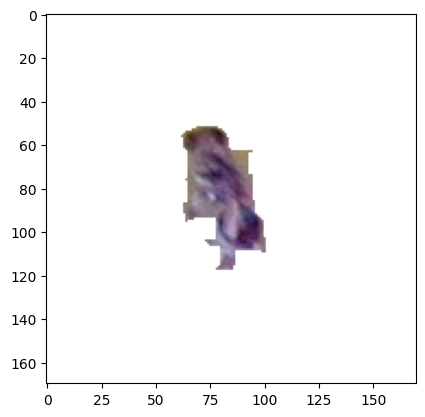

In [3]:
img = cv2.imread('Dataset-for-miniproject/olive_fly/IMG_0597 489 referencia.JPG')
foreground, mask = extract_foreground(img)

# convert from OpenCV BGR to RGB expected by Matplotlib
foreground =  cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB)
plt.imshow(foreground)
plt.show()